In [9]:
import pandas as pd


file_path = "C:/Users/HP/Desktop/Github/MachineLearning/grad independent study/Combined Data.csv"
df = pd.read_csv(file_path)

# Display basic info
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [10]:
print(df.head())

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [11]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
print(df.head())

                                           statement   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3  I've shifted my focus to something else but I'...  Anxiety
4  I'm restless and restless, it's been a month n...  Anxiety


In [12]:
print(df.describe())

                statement  status
count               52681   53043
unique              51073       7
top     what do you mean?  Normal
freq                   22   16351


In [13]:
unique_status_values = df['status'].unique()
print(unique_status_values)

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


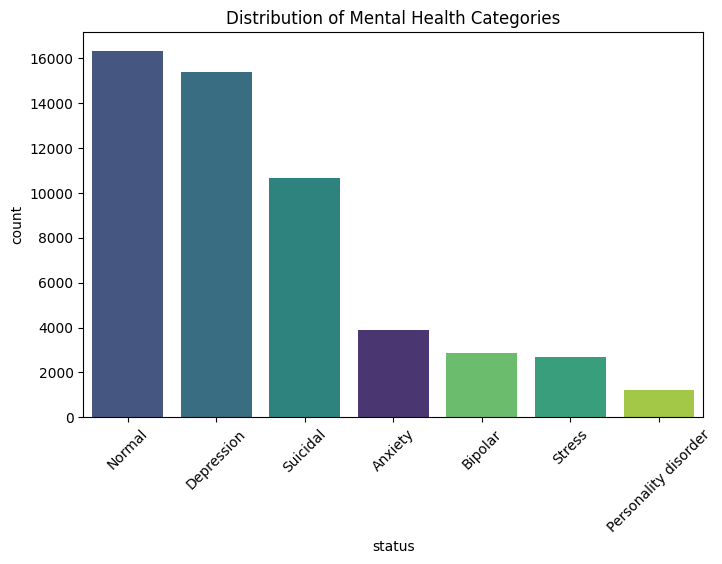


Category Distribution:
 status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

# Assigning 'hue' to the same variable as 'x' and disabling the legend
sns.countplot(data=df, x="status", order=df['status'].value_counts().index, hue="status", palette="viridis", legend=False)

plt.title("Distribution of Mental Health Categories")
plt.xticks(rotation=45)
plt.show()
print("\nCategory Distribution:\n", df['status'].value_counts())

In [ ]:
# 1 checking and handling null values

In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()  
    text = re.sub(r'\d+', '', text) 
    text = text.translate(str.maketrans('', '', string.punctuation))  
    text = text.strip() 
    return text

df['statement'] = df['statement'].apply(clean_text) 

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['statement'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
!pip install textblob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob  
def get_sentiment_score(text):
    if pd.isna(text):  # Handle missing values
        return 0  # Neutral
    return TextBlob(text).sentiment.polarity  # Returns a value between -1 and 1

df['Sentiment_Score'] = df['statement'].apply(get_sentiment_score)


In [14]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 statement    362
status         0
dtype: int64


In [ ]:
print(df['statement'].value_counts())

In [ ]:
print(df['status'].value_counts())

In [8]:
"""# Remove rows where 'statement' values is missing
df_clean = df.dropna(subset=['statement'])

# Check the class distribution of 'status' after removing missing 'statement' rows
print(f'Class distribution after removing missing statement values: {df_clean["status"].value_counts()}')

Class distribution after removing missing statement values: status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64
"""


Class distribution after removing missing statement values: status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [16]:
# Class distribution before filling
print(f'Class distribution before filling missing statement values: {df["status"].value_counts()}')

# Fill missing values in 'statement' column with the mode
#df['statement'].fillna(df['statement'].mode()[0], inplace=True)
df['statement'] = df['statement'].fillna(df['statement'].mode()[0])

# Class distribution after filling
print(f'Class distribution after filling missing statement values: {df["status"].value_counts()}')


Class distribution before filling missing statement values: status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64
Class distribution after filling missing statement values: status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_492\106554466.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['statement'].fillna(df['statement'].mode()[0], inplace=True)


In [17]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 statement    0
status       0
dtype: int64


In [ ]:
#use td idf 

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Split your data into features (X) and target (y)
X = df['statement']
y = df['status']

# 2. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize CountVectorizer and TF-IDF Vectorizer
count_vectorizer = CountVectorizer(max_features=1000, stop_words='english')
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')

# 4. Apply CountVectorizer and TF-IDF Vectorizer
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 5. Train a model and evaluate performance with CountVectorizer features
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_count, y_train)
y_pred_count = clf.predict(X_test_count)
acc_count = accuracy_score(y_test, y_pred_count)

# 6. Train a model and evaluate performance with TF-IDF features
clf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

# 7. Compare the performance of CountVectorizer and TF-IDF
print(f'Accuracy with CountVectorizer: {acc_count}')
print(f'Accuracy with TF-IDF: {acc_tfidf}')



In [ ]:
# 8. Perform Cross-validation with CountVectorizer
count_cv_scores = cross_val_score(clf, X_train_count, y_train, cv=5, scoring='accuracy')
print(f'CountVectorizer cross-validation scores: {count_cv_scores}')
print(f'Mean accuracy with CountVectorizer: {np.mean(count_cv_scores)}')




In [ ]:
# 9. Perform Cross-validation with TF-IDF
tfidf_cv_scores = cross_val_score(clf, X_train_tfidf, y_train, cv=5, scoring='accuracy')
print(f'TF-IDF cross-validation scores: {tfidf_cv_scores}')
print(f'Mean accuracy with TF-IDF: {np.mean(tfidf_cv_scores)}')



In [ ]:
# 10. Based on cross-validation, you choose CountVectorizer as the best method if it has higher mean accuracy
print(f"Best method based on cross-validation: {'CountVectorizer' if np.mean(count_cv_scores) > np.mean(tfidf_cv_scores) else 'TF-IDF'}")



In [ ]:
# 11. Apply SMOTE to CountVectorizer features after cross-validation
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res_count, y_train_res_count = smote.fit_resample(X_train_count, y_train)

# 12. Perform Cross-validation again after applying SMOTE
count_cv_scores_smote = cross_val_score(clf, X_train_res_count, y_train_res_count, cv=5, scoring='accuracy')

# 13. Display results for SMOTE
print(f'CountVectorizer with SMOTE cross-validation scores: {count_cv_scores_smote}')
print(f'Mean accuracy with CountVectorizer and SMOTE: {np.mean(count_cv_scores_smote)}')

In [10]:
#checking for class imbalance 
 #since normal,depression are majority classes while stress,bipolar,disorder are minor using the smote(Synthetic Minority Over-sampling Technique)
#will be helpful to balance the classes

Unnamed: 0      0
statement     362
status          0
dtype: int64


statement
No text provided                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                362
what do you mean?                                                                         

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


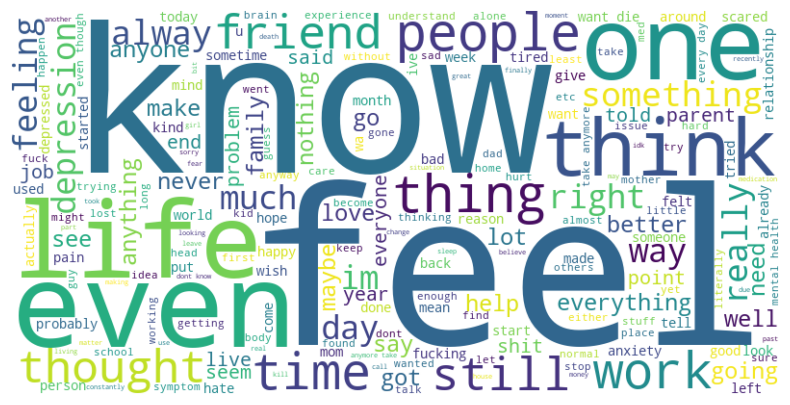

In [10]:
!pip install textblob


   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
   - ------------------------------------- 30.7/624.3 kB 145.2 kB/s eta 0:00:05
   - ------------------------------------- 30.7/624.3 kB 145.2 kB/s eta 0:00:05
   ---- ---------------------------------- 71.7/624.3 kB 245.8 kB/s eta 0:00:03
   ------ ------------------------------- 102.4/624.3 kB 328.0 kB/s eta 0:00:02
   ------------ ------------------------- 204.8/624.3 kB 565.6 kB/s eta 0:00:01
   --------------- ---------------------- 256.0/624.3 kB 655.4 kB/s eta 0:00:01
   ---------------- --------------------- 266.2/624.3 kB 630.5 kB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob  


In [13]:
def get_sentiment_score(text):
    if pd.isna(text):  # Handle missing values
        return 0  # Neutral
    return TextBlob(text).sentiment.polarity  # Returns a value between -1 and 1

df['Sentiment_Score'] = df['statement'].apply(get_sentiment_score)


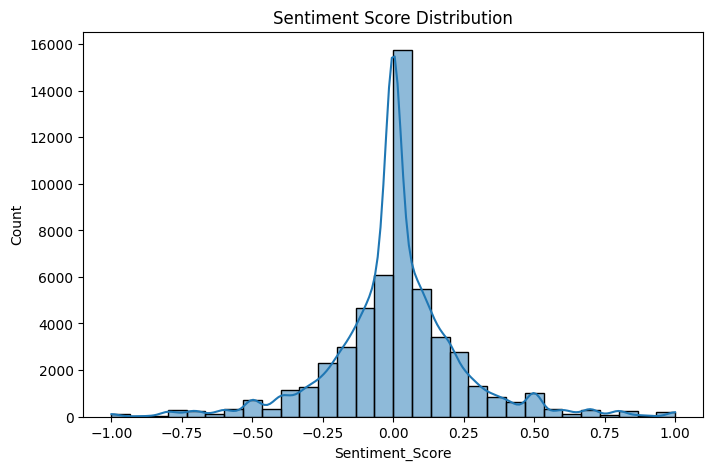

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sentiment_Score'], kde=True, bins=30)
plt.title("Sentiment Score Distribution")
plt.show()


In [15]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])  # Get sentiment score
df['sentiment_label'] = df['sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))

print(df[['clean_text', 'sentiment', 'sentiment_label']].head())


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                          clean_text  sentiment  \
0                                            oh gosh     0.0000   
1  trouble sleeping confused mind restless heart ...    -0.7269   
2  wrong back dear forward doubt stay restless re...    -0.7351   
3  ive shifted focus something else im still worried    -0.2960   
4                im restless restless month boy mean    -0.4939   

  sentiment_label  
0         neutral  
1        negative  
2        negative  
3        negative  
4        negative  
